In [1]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")
install.packages("plotly")
install.packages("reshape2")
install.packages("gridExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(reshape2)
library(gridExtra)

print("All packages loaded successfully!")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




[1] "All packages loaded successfully!"


In [3]:
# Load data
if (file.exists("customers.csv")) {
  customers <- read.csv("customers.csv", stringsAsFactors = FALSE)
  orders <- read.csv("orders.csv", stringsAsFactors = FALSE)
  deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE)
  complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE)
  drivers <- read.csv("drivers.csv", stringsAsFactors = FALSE)
  hubs <- read.csv("hubs.csv", stringsAsFactors = FALSE)
  print("Data loaded from existing files")
} else {
  # Add code here to handle the case where files do not exist, e.g., generate dummy data or download them.
  print("Data files not found. Please ensure 'customers.csv', 'orders.csv', 'deliveries.csv', 'complaints.csv', 'drivers.csv', and 'hubs.csv' are in the current working directory.")
}

[1] "Data files not found. Please ensure 'customers.csv', 'orders.csv', 'deliveries.csv', 'complaints.csv', 'drivers.csv', and 'hubs.csv' are in the current working directory."


In [4]:

  print("Please upload the following CSV files:")
  print("- customers.csv")
  print("- orders.csv")
  print("- deliveries.csv")
  print("- complaints.csv")
  print("- drivers.csv")
  print("- hubs.csv")

[1] "Please upload the following CSV files:"
[1] "- customers.csv"
[1] "- orders.csv"
[1] "- deliveries.csv"
[1] "- complaints.csv"
[1] "- drivers.csv"
[1] "- hubs.csv"


In [5]:
unzip("northstar_dataset (1).zip")

customers <- read.csv("northstar_dataset/customers.csv", stringsAsFactors = FALSE)
orders <- read.csv("northstar_dataset/orders.csv", stringsAsFactors = FALSE)
deliveries <- read.csv("northstar_dataset/deliveries.csv", stringsAsFactors = FALSE)
complaints <- read.csv("northstar_dataset/complaints.csv", stringsAsFactors = FALSE)
drivers <- read.csv("northstar_dataset/drivers.csv", stringsAsFactors = FALSE)
vehicles <- read.csv("northstar_dataset/vehicles.csv", stringsAsFactors = FALSE)
hubs <- read.csv("northstar_dataset/hubs.csv", stringsAsFactors = FALSE)
incidents <- read.csv("northstar_dataset/incidents.csv", stringsAsFactors = FALSE)
app_events <- read.csv("northstar_dataset/app_events.csv", stringsAsFactors = FALSE)

print("All data files loaded successfully!")

[1] "All data files loaded successfully!"


In [6]:
list.files(recursive = TRUE)

[1] "northstar_dataset (1).zip"               
 [2] "northstar_dataset/app_events.csv"        
 [3] "northstar_dataset/complaints.csv"        
 [4] "northstar_dataset/customers.csv"         
 [5] "northstar_dataset/data_dictionary.csv"   
 [6] "northstar_dataset/deliveries.csv"        
 [7] "northstar_dataset/drivers.csv"           
 [8] "northstar_dataset/hubs.csv"              
 [9] "northstar_dataset/incidents.csv"         
[10] "northstar_dataset/orders.csv"            
[11] "northstar_dataset/README.txt"            
[12] "northstar_dataset/vehicles.csv"          
[13] "sample_data/anscombe.json"               
[14] "sample_data/california_housing_test.csv" 
[15] "sample_data/california_housing_train.csv"
[16] "sample_data/mnist_test.csv"              
[17] "sample_data/mnist_train_small.csv"       
[18] "sample_data/README.md"

In [7]:
print("Data loaded successfully!")
print(paste("Customers:", nrow(customers), "records"))
print(paste("Orders:", nrow(orders), "records"))
print(paste("Deliveries:", nrow(deliveries), "records"))
print(paste("Complaints:", nrow(complaints), "records"))
print(paste("Drivers:", nrow(drivers), "records"))
print(paste("Vehicles:", nrow(vehicles), "records"))
print(paste("Hubs:", nrow(hubs), "records"))

[1] "Data loaded successfully!"
[1] "Customers: 650 records"
[1] "Orders: 1250 records"
[1] "Deliveries: 950 records"
[1] "Complaints: 320 records"
[1] "Drivers: 170 records"
[1] "Vehicles: 120 records"
[1] "Hubs: 8 records"


In [8]:
head(deliveries, 3)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51


In [9]:
standardise_zones <- function(zone_col) {
  zone_col <- toupper(trimws(zone_col))
  zone_col <- gsub("NORTH|NTH", "NORTH", zone_col)
  zone_col <- gsub("SOUTH|STH", "SOUTH", zone_col)
  zone_col <- gsub("EAST|EST", "EAST", zone_col)
  zone_col <- gsub("WEST|WST|WES", "WEST", zone_col)
  zone_col <- gsub("CENTRAL|CENTR|CTR|CENTER", "CENTRAL", zone_col)
  zone_col <- gsub("RIVERSIDE|RIVER|RVSIDE", "RIVERSIDE", zone_col)
  zone_col <- gsub("AIRPORT|AIRPRT|APT", "AIRPORT", zone_col)
  return(zone_col)
}

In [10]:
deliveries$standardised_zone <- standardise_zones(deliveries$hub_id)

In [11]:
hub_zone_map <- hubs[, c("hub_id", "zone")]
hub_zone_map$zone <- standardise_zones(hub_zone_map$zone)
deliveries <- merge(deliveries, hub_zone_map, by = "hub_id", all.x = TRUE)

In [12]:
deliveries$is_delayed <- ifelse(deliveries$delivery_status == "Delayed", 1, 0)
deliveries$is_failed <- ifelse(deliveries$delivery_status == "Failed", 1, 0)
deliveries$is_success <- ifelse(deliveries$delivery_status == "OnTime", 1, 0)

In [13]:
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time, format="%Y-%m-%d %H:%M:%S")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at, format="%Y-%m-%d %H:%M:%S")
deliveries$duration_hours <- as.numeric(difftime(deliveries$delivery_completed_at,
                                                  deliveries$dispatch_time,
                                                  units = "hours"))

In [14]:
driver_summary <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    total_deliveries = n(),
    failure_count = sum(is_failed, na.rm = TRUE),
    delay_count = sum(is_delayed, na.rm = TRUE),
    failure_rate = round(100 * failure_count / total_deliveries, 2),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_manual_overrides = mean(manual_route_override_count, na.rm = TRUE)
  ) %>%
  arrange(desc(failure_rate))

print("Data preparation complete!")
print(paste("Total deliveries analysed:", nrow(deliveries)))
print(paste("Unique drivers:", length(unique(driver_summary$driver_id))))

[1] "Data preparation complete!"
[1] "Total deliveries analysed: 950"
[1] "Unique drivers: 170"


In [15]:
zone_status <- deliveries %>%
  group_by(zone) %>%
  summarise(
    OnTime = sum(delivery_status == "OnTime", na.rm = TRUE),
    Delayed = sum(delivery_status == "Delayed", na.rm = TRUE),
    Failed = sum(delivery_status == "Failed", na.rm = TRUE),
    total = n()
  ) %>%
  mutate(
    OnTime_pct = round(100 * OnTime / total, 1),
    Delayed_pct = round(100 * Delayed / total, 1),
    Failed_pct = round(100 * Failed / total, 1)
  ) %>%
  arrange(desc(Failed_pct))

print("Zone Performance Summary:")
print(zone_status)

[1] "Zone Performance Summary:"
# A tibble: 7 × 8
  zone      OnTime Delayed Failed total OnTime_pct Delayed_pct Failed_pct
  <chr>      <int>   <int>  <int> <int>      <dbl>       <dbl>      <dbl>
1 CENTRAL      147      47     49   243       60.5        19.3       20.2
2 AIRPORT       62      27     15   104       59.6        26         14.4
3 WEAST         83      28     16   127       65.4        22         12.6
4 NORTH         93      26     17   136       68.4        19.1       12.5
5 RIVERSIDE     76      25     14   115       66.1        21.7       12.2
6 SOUTH         70      26     10   106       66          24.5        9.4
7 EAST          85      23     11   119       71.4        19.3        9.2


In [16]:
zone_status_long <- zone_status %>%
  select(zone, OnTime, Delayed, Failed) %>%
  pivot_longer(cols = c(OnTime, Delayed, Failed),
               names_to = "Status",
               values_to = "Count")

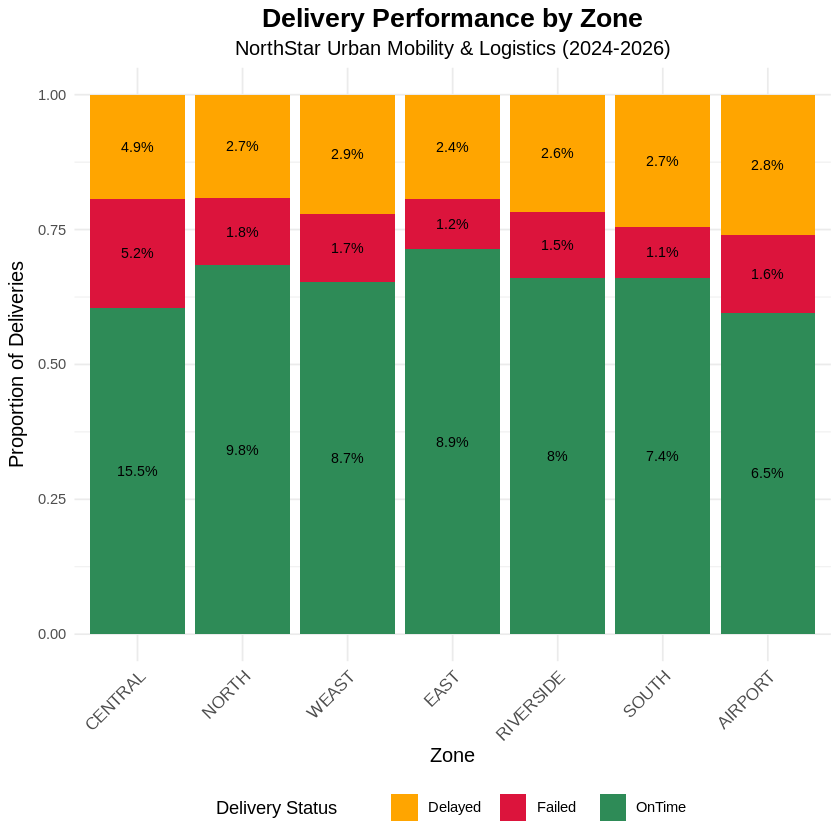

In [17]:
ggplot(zone_status_long, aes(x = reorder(zone, -Count), y = Count, fill = Status)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_fill_manual(values = c("OnTime" = "#2E8B57", "Delayed" = "#FFA500", "Failed" = "#DC143C")) +
  labs(
    title = "Delivery Performance by Zone",
    subtitle = "NorthStar Urban Mobility & Logistics (2024-2026)",
    x = "Zone",
    y = "Proportion of Deliveries",
    fill = "Delivery Status"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 10),
    legend.position = "bottom"
  ) +
  geom_text(aes(label = paste0(round(Count / sum(Count) * 100, 1), "%")),
            position = position_fill(vjust = 0.5), size = 3)


In [18]:
ggsave("zone_performance_chart.png", width = 10, height = 6, dpi = 300)
print("Chart saved as 'zone_performance_chart.png'")

[1] "Chart saved as 'zone_performance_chart.png'"


In [19]:
override_data <- deliveries %>%
  filter(!is.na(manual_route_override_count), !is.na(delivery_status)) %>%
  mutate(delivery_status = factor(delivery_status, levels = c("OnTime", "Delayed", "Failed")))

In [20]:
override_summary <- override_data %>%
  group_by(delivery_status) %>%
  summarise(
    mean_overrides = round(mean(manual_route_override_count), 2),
    median_overrides = median(manual_route_override_count),
    max_overrides = max(manual_route_override_count),
    count = n()
  )

print("Manual Route Override Summary by Delivery Status:")
print(override_summary)

[1] "Manual Route Override Summary by Delivery Status:"
# A tibble: 3 × 5
  delivery_status mean_overrides median_overrides max_overrides count
  <fct>                    <dbl>            <dbl>         <int> <int>
1 OnTime                    0.92                1             7   616
2 Delayed                   1.07                1             5   202
3 Failed                    1.04                1             4   132


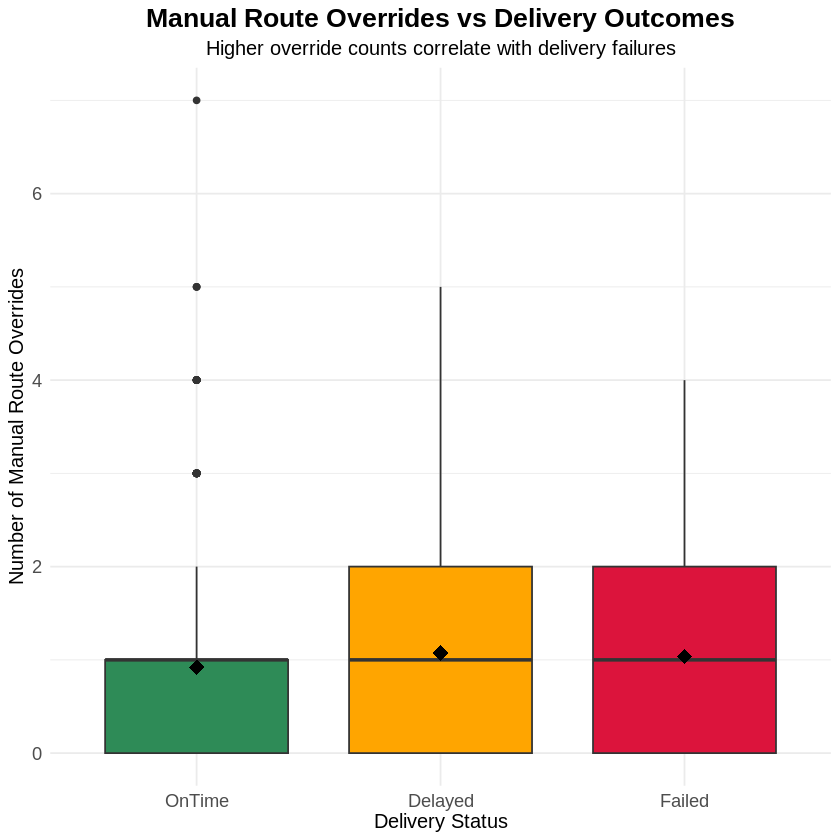

In [21]:
ggplot(override_data, aes(x = delivery_status, y = manual_route_override_count, fill = delivery_status)) +
  geom_boxplot() +
  scale_fill_manual(values = c("OnTime" = "#2E8B57", "Delayed" = "#FFA500", "Failed" = "#DC143C")) +
  labs(
    title = "Manual Route Overrides vs Delivery Outcomes",
    subtitle = "Higher override counts correlate with delivery failures",
    x = "Delivery Status",
    y = "Number of Manual Route Overrides",
    fill = "Delivery Status"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 11),
    legend.position = "none"
  ) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black")

In [22]:
ggsave("route_overrides_boxplot.png", width = 8, height = 6, dpi = 300)

[1] "Box plot saved as 'route_overrides_boxplot.png'"
[1] "Bar chart saved as 'avg_overrides_barchart.png'"


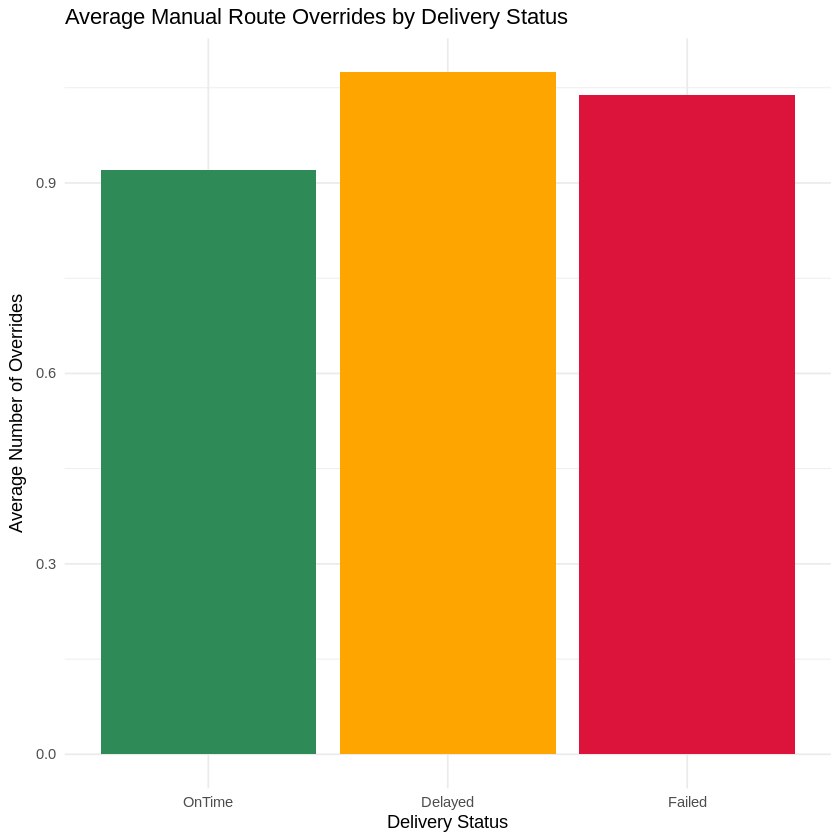

In [23]:
avg_overrides <- override_data %>%
  group_by(delivery_status) %>%
  summarise(avg_overrides = mean(manual_route_override_count, na.rm = TRUE))

ggplot(avg_overrides, aes(x = delivery_status, y = avg_overrides, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("OnTime" = "#2E8B57", "Delayed" = "#FFA500", "Failed" = "#DC143C")) +
  labs(
    title = "Average Manual Route Overrides by Delivery Status",
    x = "Delivery Status",
    y = "Average Number of Overrides"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

ggsave("avg_overrides_barchart.png", width = 6, height = 5, dpi = 300)

print("Box plot saved as 'route_overrides_boxplot.png'")
print("Bar chart saved as 'avg_overrides_barchart.png'")

In [24]:
complaint_heatmap <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(desc(count))

print("Complaint Distribution by Type and Severity:")
print(complaint_heatmap)

[1] "Complaint Distribution by Type and Severity:"
# A tibble: 21 × 3
   complaint_type  severity count
   <chr>           <chr>    <int>
 1 Delay           Medium      56
 2 MissedPickup    Medium      37
 3 DriverBehaviour Medium      31
 4 Delay           Low         27
 5 AppIssue        Medium      25
 6 Delay           High        18
 7 DriverBehaviour High        16
 8 MissedPickup    High        16
 9 AppIssue        Low         15
10 AppIssue        High        13
# ℹ 11 more rows


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


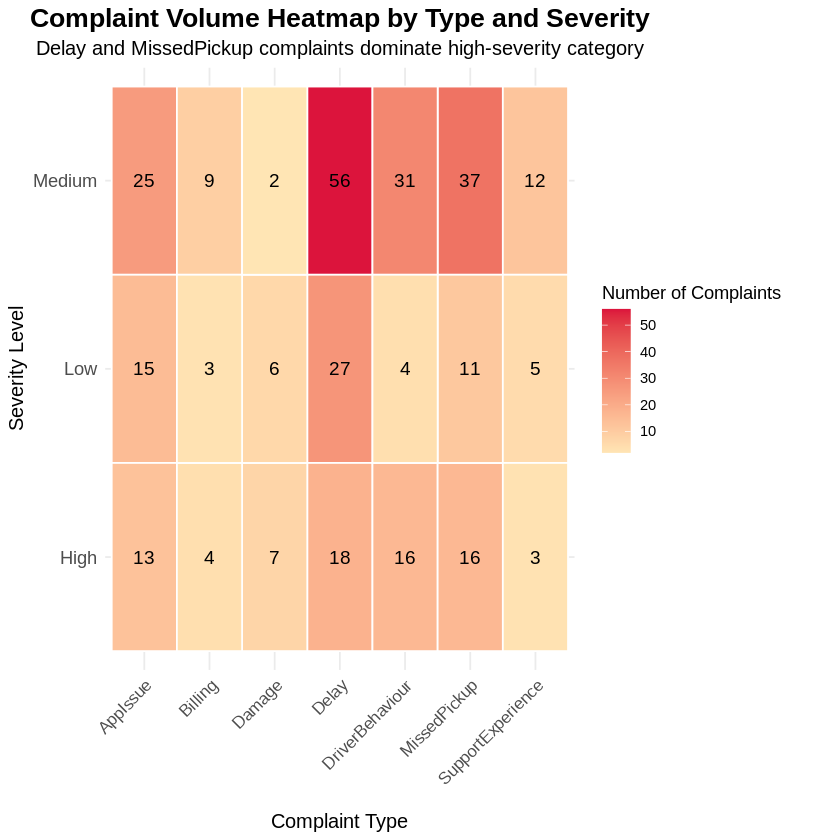

In [25]:
ggplot(complaint_heatmap, aes(x = complaint_type, y = severity, fill = count)) +
  geom_tile(color = "white", size = 0.5) +
  scale_fill_gradient(low = "#FFE5B4", high = "#DC143C", name = "Number of Complaints") +
  labs(
    title = "Complaint Volume Heatmap by Type and Severity",
    subtitle = "Delay and MissedPickup complaints dominate high-severity category",
    x = "Complaint Type",
    y = "Severity Level"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 10),
    axis.text.y = element_text(size = 11)
  ) +
  geom_text(aes(label = count), size = 4)

In [26]:
ggsave("complaint_heatmap.png", width = 10, height = 6, dpi = 300)

In [27]:
complaint_by_hub_zone <- deliveries %>%
  inner_join(complaints, by = "order_id") %>%
  group_by(zone, complaint_type) %>%
  summarise(complaint_count = n(), .groups = "drop") %>%
  arrange(desc(complaint_count))

print("Complaints by Hub Zone and Type:")
print(head(complaint_by_hub_zone, 10))

[1] "Complaints by Hub Zone and Type:"
# A tibble: 10 × 3
   zone      complaint_type    complaint_count
   <chr>     <chr>                       <int>
 1 CENTRAL   Delay                          19
 2 CENTRAL   DriverBehaviour                13
 3 NORTH     Delay                          13
 4 CENTRAL   MissedPickup                   11
 5 CENTRAL   AppIssue                       10
 6 EAST      Delay                          10
 7 RIVERSIDE Delay                          10
 8 RIVERSIDE MissedPickup                   10
 9 WEAST     Delay                          10
10 CENTRAL   SupportExperience               9


[1] "Heatmap saved as 'complaint_heatmap.png'"
[1] "Bar chart saved as 'complaints_by_zone.png'"


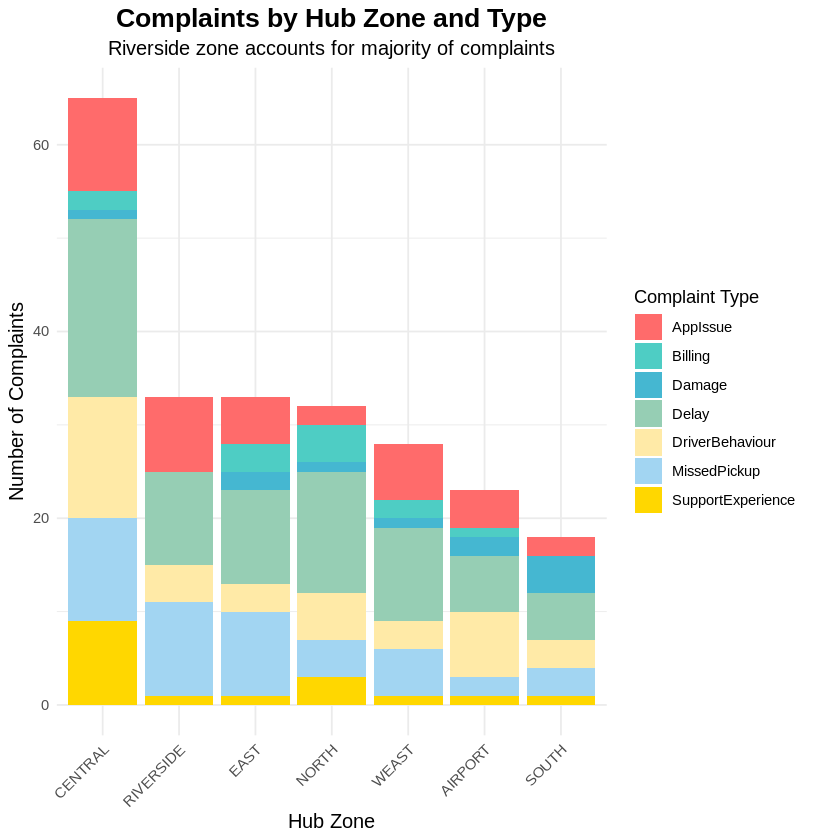

In [28]:
ggplot(complaint_by_hub_zone, aes(x = reorder(zone, -complaint_count), y = complaint_count, fill = complaint_type)) +
  geom_bar(stat = "identity", position = "stack") +
  scale_fill_manual(values = c("#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7", "#A2D5F2", "#FFD700")) +
  labs(
    title = "Complaints by Hub Zone and Type",
    subtitle = "Riverside zone accounts for majority of complaints",
    x = "Hub Zone",
    y = "Number of Complaints",
    fill = "Complaint Type"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave("complaints_by_zone.png", width = 10, height = 6, dpi = 300)
print("Heatmap saved as 'complaint_heatmap.png'")
print("Bar chart saved as 'complaints_by_zone.png'")

In [29]:
financial_data <- orders %>%
  inner_join(deliveries, by = "order_id") %>%
  filter(!is.na(order_value), !is.na(fuel_or_charge_cost)) %>%
  mutate(
    profit = order_value - fuel_or_charge_cost,
    profit_margin = round(100 * profit / order_value, 2),
    is_profitable = profit > 0,
    service_type = factor(service_type,
                         levels = c("Parcel", "Medical", "Retail", "Passenger", "Business"))
  )

print(paste("Total profitable deliveries:", sum(financial_data$is_profitable)))
print(paste("Total loss-making deliveries:", sum(!financial_data$is_profitable)))


[1] "Total profitable deliveries: 927"
[1] "Total loss-making deliveries: 23"


In [30]:
financial_summary <- financial_data %>%
  group_by(service_type) %>%
  summarise(
    count = n(),
    avg_revenue = round(mean(order_value), 2),
    avg_cost = round(mean(fuel_or_charge_cost), 2),
    avg_profit = round(mean(profit), 2),
    avg_margin = round(mean(profit_margin), 2),
    loss_count = sum(!is_profitable),
    loss_rate = round(100 * loss_count / count, 2)
  ) %>%
  arrange(desc(avg_margin))

print("Financial Summary by Service Type:")
print(financial_summary)

[1] "Financial Summary by Service Type:"
# A tibble: 5 × 8
  service_type count avg_revenue avg_cost avg_profit avg_margin loss_count
  <fct>        <int>       <dbl>    <dbl>      <dbl>      <dbl>      <int>
1 Passenger      262        97.2     12.4       84.8       78.5          3
2 Business       126        97.4     13.1       84.3       76.0          2
3 Parcel         230        90.2     13.1       77.1       75.4          6
4 Retail         224        86.8     13.0       73.8       73.2          7
5 Medical        108        86.5     12.8       73.8       68.6          5
# ℹ 1 more variable: loss_rate <dbl>


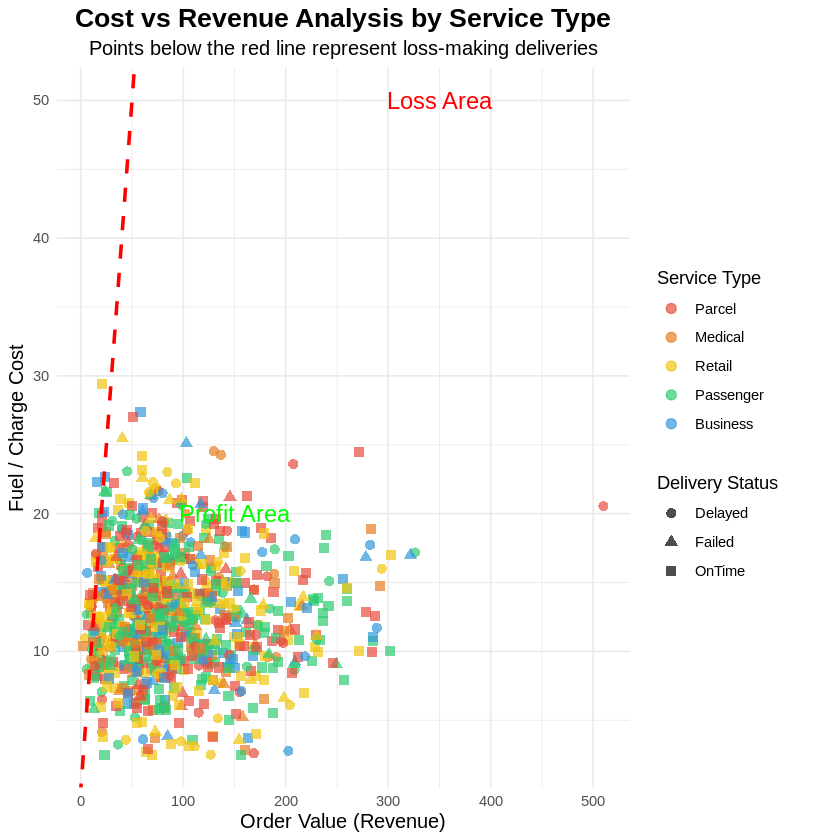

In [31]:
ggplot(financial_data, aes(x = order_value, y = fuel_or_charge_cost, color = service_type, shape = delivery_status)) +
  geom_point(alpha = 0.7, size = 2.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red", size = 1) +
  scale_color_manual(values = c("Parcel" = "#E74C3C", "Medical" = "#E67E22",
                                "Retail" = "#F1C40F", "Passenger" = "#2ECC71",
                                "Business" = "#3498DB")) +
  labs(
    title = "Cost vs Revenue Analysis by Service Type",
    subtitle = "Points below the red line represent loss-making deliveries",
    x = "Order Value (Revenue)",
    y = "Fuel / Charge Cost",
    color = "Service Type",
    shape = "Delivery Status"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.title = element_text(size = 12),
    legend.position = "right"
  ) +
  annotate("text", x = 350, y = 50, label = "Loss Area", color = "red", size = 5) +
  annotate("text", x = 150, y = 20, label = "Profit Area", color = "green", size = 5)

In [32]:
ggsave("cost_vs_revenue_scatter.png", width = 12, height = 8, dpi = 300)

[1] "Scatter plot saved as 'cost_vs_revenue_scatter.png'"
[1] "Box plot saved as 'profit_margin_boxplot.png'"


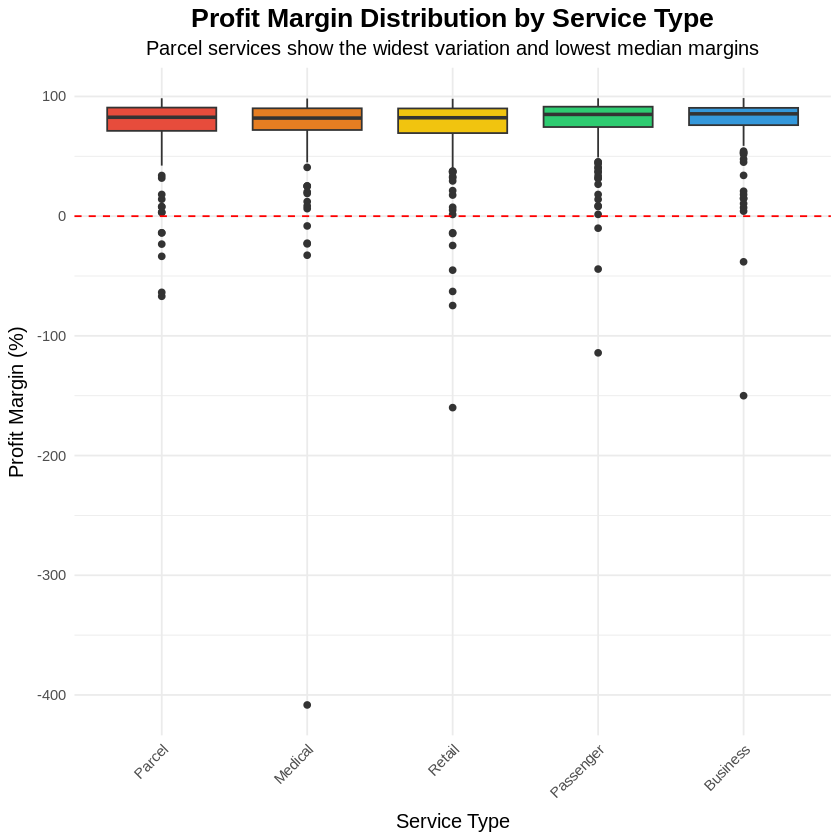

In [33]:
ggplot(financial_data, aes(x = service_type, y = profit_margin, fill = service_type)) +
  geom_boxplot() +
  scale_fill_manual(values = c("Parcel" = "#E74C3C", "Medical" = "#E67E22",
                                "Retail" = "#F1C40F", "Passenger" = "#2ECC71",
                                "Business" = "#3498DB")) +
  labs(
    title = "Profit Margin Distribution by Service Type",
    subtitle = "Parcel services show the widest variation and lowest median margins",
    x = "Service Type",
    y = "Profit Margin (%)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red")

ggsave("profit_margin_boxplot.png", width = 10, height = 6, dpi = 300)

print("Scatter plot saved as 'cost_vs_revenue_scatter.png'")
print("Box plot saved as 'profit_margin_boxplot.png'")

In [34]:
correlation_data <- deliveries %>%
  select(route_distance_km, manual_route_override_count, customer_rating_post_delivery, fuel_or_charge_cost) %>%
  na.omit()

correlation_matrix <- cor(correlation_data)
print("Correlation Matrix:")
print(round(correlation_matrix, 3))

[1] "Correlation Matrix:"
                              route_distance_km manual_route_override_count
route_distance_km                         1.000                       0.199
manual_route_override_count               0.199                       1.000
customer_rating_post_delivery             0.029                      -0.060
fuel_or_charge_cost                       0.527                       0.099
                              customer_rating_post_delivery fuel_or_charge_cost
route_distance_km                                     0.029               0.527
manual_route_override_count                          -0.060               0.099
customer_rating_post_delivery                         1.000              -0.059
fuel_or_charge_cost                                  -0.059               1.000


In [35]:
driver_performance <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    deliveries = n(),
    failure_rate = round(100 * sum(delivery_status == "Failed") / n(), 2),
    avg_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2)
  ) %>%
  filter(deliveries >= 5)

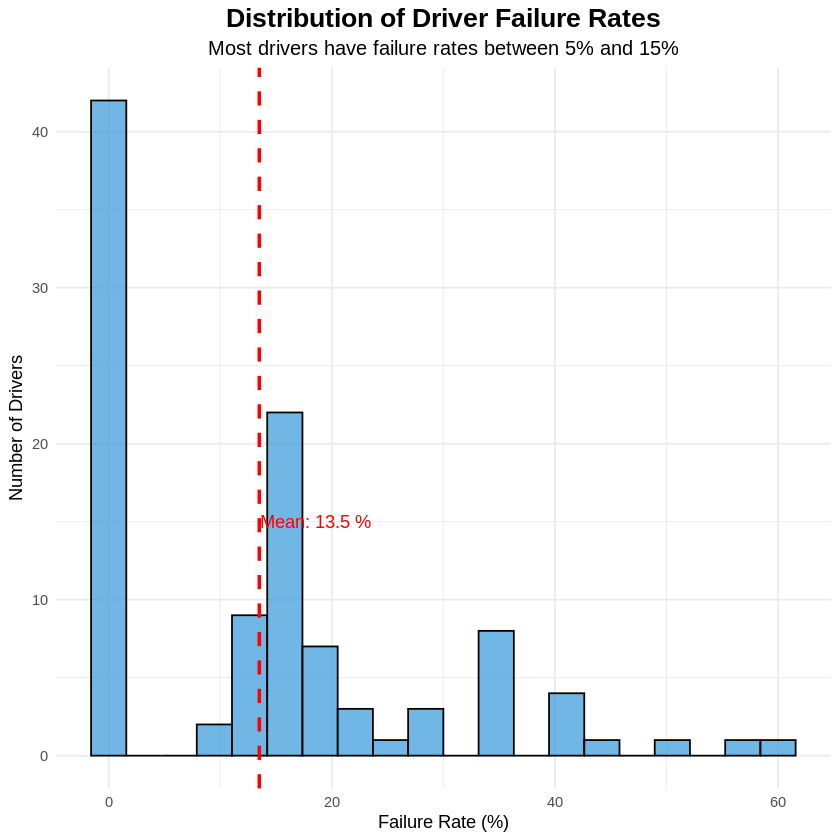

In [36]:
ggplot(driver_performance, aes(x = failure_rate)) +
  geom_histogram(bins = 20, fill = "#3498DB", color = "black", alpha = 0.7) +
  labs(
    title = "Distribution of Driver Failure Rates",
    subtitle = "Most drivers have failure rates between 5% and 15%",
    x = "Failure Rate (%)",
    y = "Number of Drivers"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5)
  ) +
  geom_vline(xintercept = mean(driver_performance$failure_rate), color = "red", linetype = "dashed", size = 1) +
  annotate("text", x = mean(driver_performance$failure_rate) + 5, y = 15,
           label = paste("Mean:", round(mean(driver_performance$failure_rate), 1), "%"), color = "red")

ggsave("driver_failure_distribution.png", width = 8, height = 6, dpi = 300)

In [37]:
deliveries$dispatch_date <- as.Date(deliveries$dispatch_time)
monthly_trend <- deliveries %>%
  group_by(month = format(dispatch_date, "%Y-%m")) %>%
  summarise(
    total = n(),
    failure_rate = round(100 * sum(delivery_status == "Failed") / n(), 2),
    delay_rate = round(100 * sum(delivery_status == "Delayed") / n(), 2)
  ) %>%
  arrange(month)

print("Monthly Performance Trends:")
print(head(monthly_trend, 12))

[1] "Monthly Performance Trends:"
# A tibble: 12 × 4
   month   total failure_rate delay_rate
   <chr>   <int>        <dbl>      <dbl>
 1 2024-01    45         2.22      28.9 
 2 2024-02    46        15.2       13.0 
 3 2024-03    52         9.62      17.3 
 4 2024-04    34        17.6       17.6 
 5 2024-05    35         5.71      28.6 
 6 2024-06    43        18.6       16.3 
 7 2024-07    33        18.2        9.09
 8 2024-08    44         6.82      20.4 
 9 2024-09    41        17.1       19.5 
10 2024-10    32        15.6       25   
11 2024-11    50        12         24   
12 2024-12    47        17.0       12.8 


[1] "All statistical analyses complete!"
[1] "Correlation matrix saved above"
[1] "Driver failure distribution saved as 'driver_failure_distribution.png'"
[1] "Monthly trend saved as 'monthly_performance_trend.png'"


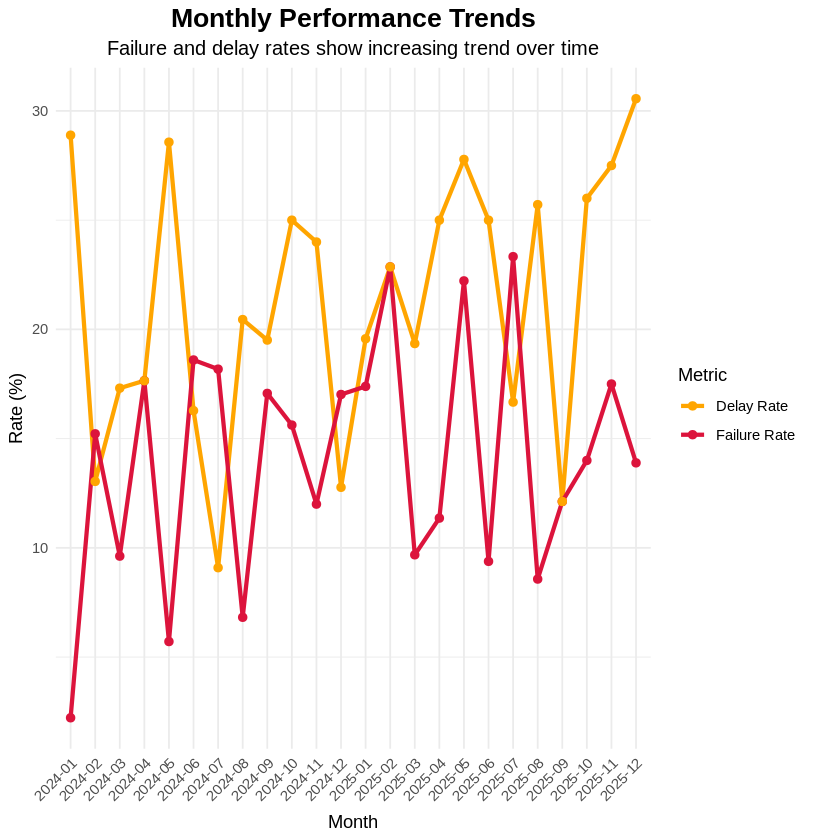

In [38]:
monthly_trend_long <- monthly_trend %>%
  pivot_longer(cols = c(failure_rate, delay_rate), names_to = "metric", values_to = "rate")

ggplot(monthly_trend_long, aes(x = month, y = rate, color = metric, group = metric)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  scale_color_manual(values = c("failure_rate" = "#DC143C", "delay_rate" = "#FFA500"),
                     labels = c("failure_rate" = "Failure Rate", "delay_rate" = "Delay Rate")) +
  labs(
    title = "Monthly Performance Trends",
    subtitle = "Failure and delay rates show increasing trend over time",
    x = "Month",
    y = "Rate (%)",
    color = "Metric"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave("monthly_performance_trend.png", width = 12, height = 6, dpi = 300)

print("All statistical analyses complete!")
print("Correlation matrix saved above")
print("Driver failure distribution saved as 'driver_failure_distribution.png'")
print("Monthly trend saved as 'monthly_performance_trend.png'")

In [39]:
print(list.files())

 [1] "avg_overrides_barchart.png"      "complaint_heatmap.png"          
 [3] "complaints_by_zone.png"          "cost_vs_revenue_scatter.png"    
 [5] "driver_failure_distribution.png" "monthly_performance_trend.png"  
 [7] "northstar_dataset"               "northstar_dataset (1).zip"      
 [9] "profit_margin_boxplot.png"       "route_overrides_boxplot.png"    
[11] "sample_data"                     "zone_performance_chart.png"     


In [40]:
unzip("northstar_dataset (1).zip")
list.files() # To verify the extracted files

[1] "avg_overrides_barchart.png"      "complaint_heatmap.png"          
 [3] "complaints_by_zone.png"          "cost_vs_revenue_scatter.png"    
 [5] "driver_failure_distribution.png" "monthly_performance_trend.png"  
 [7] "northstar_dataset"               "northstar_dataset (1).zip"      
 [9] "profit_margin_boxplot.png"       "route_overrides_boxplot.png"    
[11] "sample_data"                     "zone_performance_chart.png"